In [5]:
import pandas as pd
import numpy as np

spy_data = pd.read_csv('spy_data - Sheet1.csv')
spy_data['Date'] = pd.to_datetime(spy_data['Date']).dt.date
spy_data.set_index('Date', inplace=True)
spy_data.sort_index(inplace=True)
spy_data.dropna()
spy_data.head()

,Close
Date,
2014-01-02,182.92
2014-01-03,182.89
2014-01-06,182.36
2014-01-07,183.48
2014-01-08,183.52


In [ ]:
spy_data["log_returns"] = np.log(spy_data["Close"] / spy_data["Close"].shift(1))
spy_data.dropna(inplace=True)
spy_data["volatility"] = spy_data["log_returns"].rolling(window=30).std() * np.sqrt(252)
spy_data.dropna(inplace=True)
spy_data.head()

,Close,log_returns,volatility
Date,,,
2014-02-18,184.24,0.001195,0.141675
2014-02-19,183.02,-0.006644,0.142808
2014-02-20,184.10,0.005884,0.142722
2014-02-21,183.89,-0.001141,0.142768
2014-02-24,184.91,0.005531,0.143640


In [10]:
from sklearn.preprocessing import StandardScaler

X = spy_data[['log_returns', 'volatility']].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

c:\Users\aravn\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=12.
  warnings.warn(


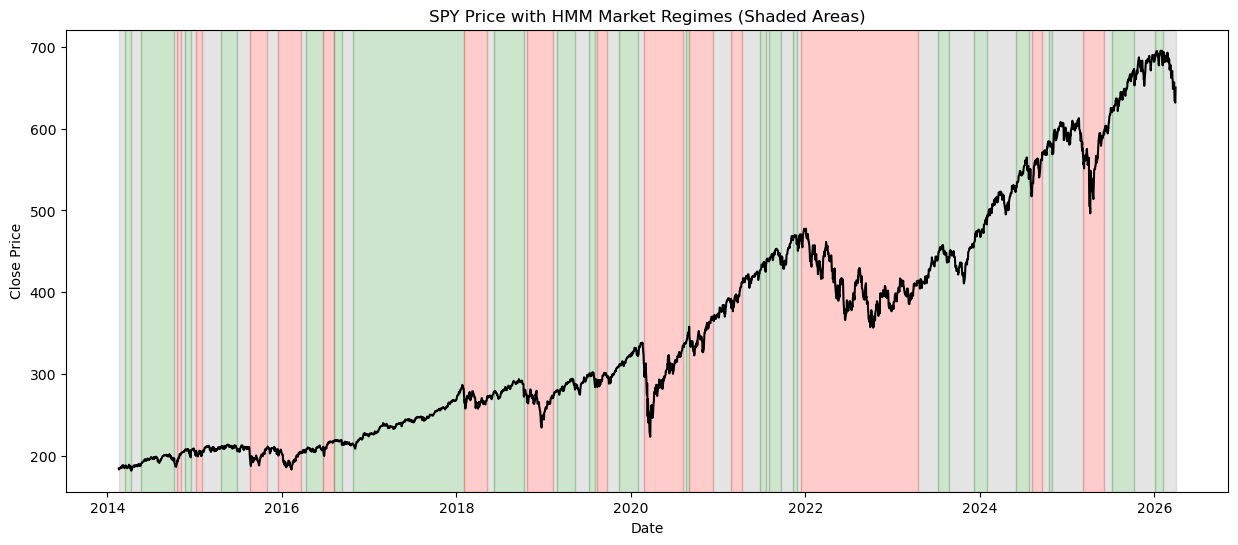

In [17]:
from hmmlearn.hmm import GaussianHMM
import matplotlib.pyplot as plt

hmm_model = GaussianHMM(n_components=3, covariance_type="full", n_iter=1000, random_state=42)
hmm_model.fit(X_scaled)

hidden_states = hmm_model.predict(X_scaled)
spy_data['state'] = hidden_states

state_means = spy_data.groupby('state')['log_returns'].mean()
sorted_states = state_means.sort_values().index

state_mapping = {
    sorted_states[0]: 'Bear',
    sorted_states[1]: 'Sideways',
    sorted_states[2]: 'Bull'
}

spy_data['regime'] = spy_data['state'].map(state_mapping)

colors = {'Bull':'green', 'Bear':'red', 'Sideways':'gray'}
plt.figure(figsize=(15,6))
plt.plot(spy_data.index, spy_data['Close'], color='black', label='SPY Close Price')

current_regime = spy_data['regime'].iloc[0]
start_idx = spy_data.index[0]

for i in range(1, len(spy_data)):
    if spy_data['regime'].iloc[i] != current_regime or i == len(spy_data)-1:
        end_idx = spy_data.index[i]
        plt.axvspan(start_idx, end_idx, color=colors[current_regime], alpha=0.2)
        current_regime = spy_data['regime'].iloc[i]
        start_idx = end_idx

plt.title("SPY Price with HMM Market Regimes (Shaded Areas)")
plt.xlabel("Date")
plt.ylabel("Close Price")
plt.show()

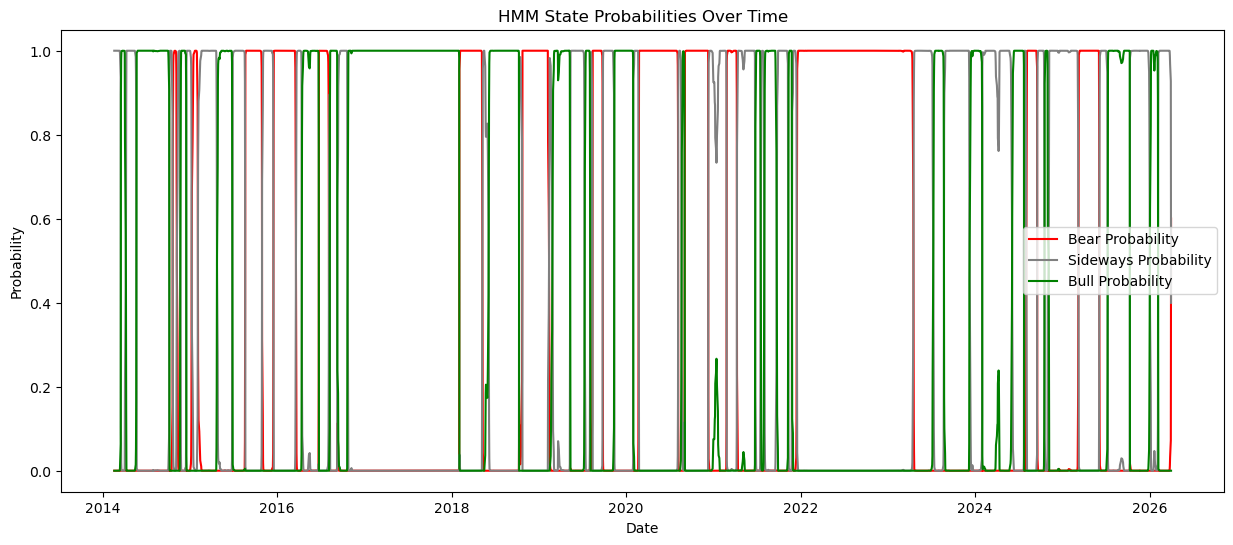

In [22]:
state_probs = hmm_model.predict_proba(X_scaled)
plt.figure(figsize=(15,6))
plt.plot(spy_data.index, state_probs[:, sorted_states[0]], label='Bear Probability', color='red')
plt.plot(spy_data.index, state_probs[:, sorted_states[1]], label='Sideways Probability', color='gray')
plt.plot(spy_data.index, state_probs[:, sorted_states[2]], label='Bull Probability', color='green')
plt.title("HMM State Probabilities Over Time")
plt.xlabel("Date")
plt.ylabel("Probability")
plt.legend()
plt.show()

In [24]:
bull_state_index = sorted_states[2]
bull_prob = state_probs[:, bull_state_index]
sigmoid_prob = 1 / (1 + np.exp(-10 * (bull_prob - 0.5)))

In [ ]:
#Moving Average Crossover for Trend Exhaustion Detection
fast_period = 3
slow_period = 8

spy_data['EMA_fast'] = spy_data['Close'].ewm(span=fast_period, adjust=False).mean()
spy_data['EMA_slow'] = spy_data['Close'].ewm(span=slow_period, adjust=False).mean()

spy_data['trend_exhaustion'] = 0
spy_data.loc[(spy_data['EMA_fast'] < spy_data['EMA_slow']) &
             (spy_data['EMA_fast'].shift(1) >= spy_data['EMA_slow'].shift(1)), 'trend_exhaustion'] = -1
spy_data.loc[(spy_data['EMA_fast'] > spy_data['EMA_slow']) &
             (spy_data['EMA_fast'].shift(1) <= spy_data['EMA_slow'].shift(1)), 'trend_exhaustion'] = 1

#Volatility Breakout Detection
fast_window = 5
slow_window = 20
threshold = 1.5 

spy_data['vol_fast'] = spy_data['log_returns'].rolling(window=fast_window).std()
spy_data['vol_slow'] = spy_data['log_returns'].rolling(window=slow_window).mean()
spy_data['vol_breakout'] = 0
spy_data.loc[spy_data['vol_fast'] > threshold * spy_data['vol_slow'], 'vol_breakout'] = 1

#Breadth Deterioration Detection
spy_data['SMA50'] = spy_data['Close'].rolling(window=50).mean()
spy_data['breadth_deterioration'] = 0

spy_data.loc[
    (spy_data['regime'] == 'Bull') &
    (spy_data['Close'] < spy_data['SMA50']),
    'breadth_deterioration'
] = -1

#Momentum Divergence Detection
def compute_rsi(series, period=14):
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    
    avg_gain = gain.ewm(alpha=1/period, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1/period, adjust=False).mean()
    
    rs = avg_gain / avg_loss
    rsi = 100 - (100 / (1 + rs))
    return rsi

spy_data['RSI'] = compute_rsi(spy_data['Close'])
spy_data['High20'] = spy_data['Close'].rolling(window=20).max()
spy_data['momentum_divergence'] = 0

spy_data.loc[
    (spy_data['RSI'] < 45) &
    (spy_data['Close'] >= 0.95 * spy_data['High20']) &
    (spy_data['regime'] == 'Bull'),
    'momentum_divergence'
] = -1

#Regime Scoring
spy_data['trend_green'] = (spy_data['trend_exhaustion'] >= 0).astype(int)
spy_data['vol_green'] = (spy_data['vol_breakout'] == 0).astype(int)
spy_data['breadth_green'] = (spy_data['breadth_deterioration'] == 0).astype(int)
spy_data['momentum_green'] = (spy_data['momentum_divergence'] == 0).astype(int)
spy_data['regime_score'] = (spy_data['trend_green'] + spy_data['vol_green'] + spy_data['breadth_green'] + spy_data['momentum_green'])

#Portfolio Construction
spy_data['position_spy'] = 0.0
spy_data.loc[spy_data['regime'] == 'Bull', 'position_spy'] = spy_data['regime_score'].map({
    4: 1.5,
    3: 1.0,
    2: 0.5,
    1: 0.0,
    0: 0.0
})
spy_data.loc[spy_data['regime'] == 'Bear', 'position_spy'] = -0.5

spy_data['ret_spy'] = spy_data['Close'].pct_change()
spy_data['daily_return'] = spy_data['position_spy'] * spy_data['log_returns']
cash = 100000
portfolio = cash
portfolio_values = []

for i in range(len(spy_data)):
    if i == 0:
        portfolio_values.append(portfolio)
        continue
    
    daily_pnl = (spy_data['position_spy'].iloc[i] * portfolio * spy_data['ret_spy'].iloc[i])
    
    portfolio += daily_pnl
    portfolio_values.append(portfolio)

spy_data['portfolio'] = portfolio_values

spy_data.index = pd.to_datetime(spy_data.index)
spy_data['year'] = spy_data.index.year
spy_data['daily_portfolio_ret'] = spy_data['portfolio'].pct_change()

for y in spy_data['year'].unique():
    year_mask = spy_data['year'] == y
    cumulative_ret = (1 + spy_data.loc[year_mask, 'daily_portfolio_ret']).cumprod()
    
    drawdown = cumulative_ret / cumulative_ret.cummax() - 1
    if (drawdown < -0.08).any():
        spy_data.loc[year_mask, 'position_spy'] = 0

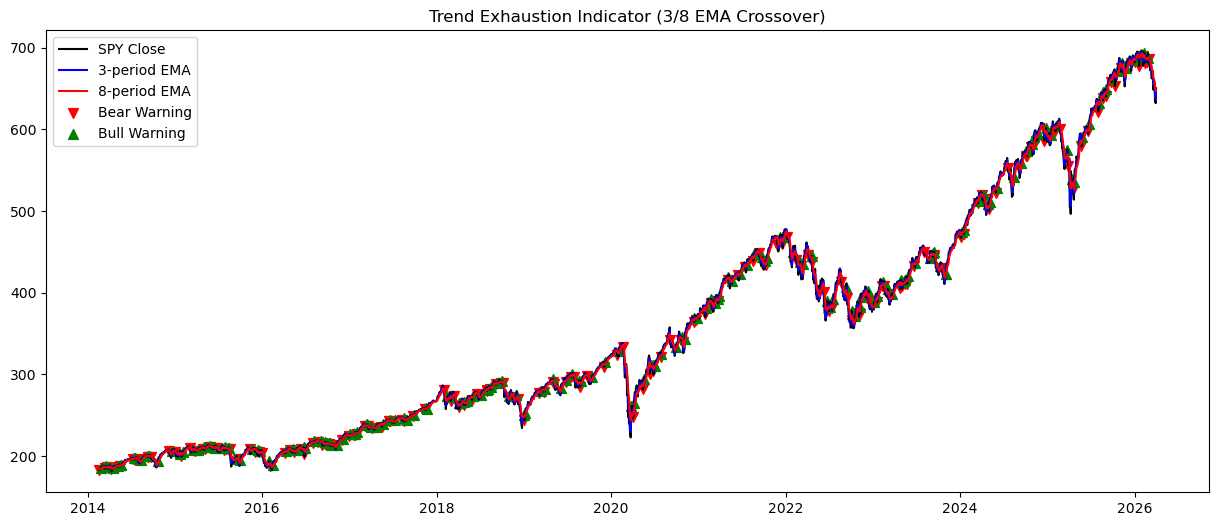

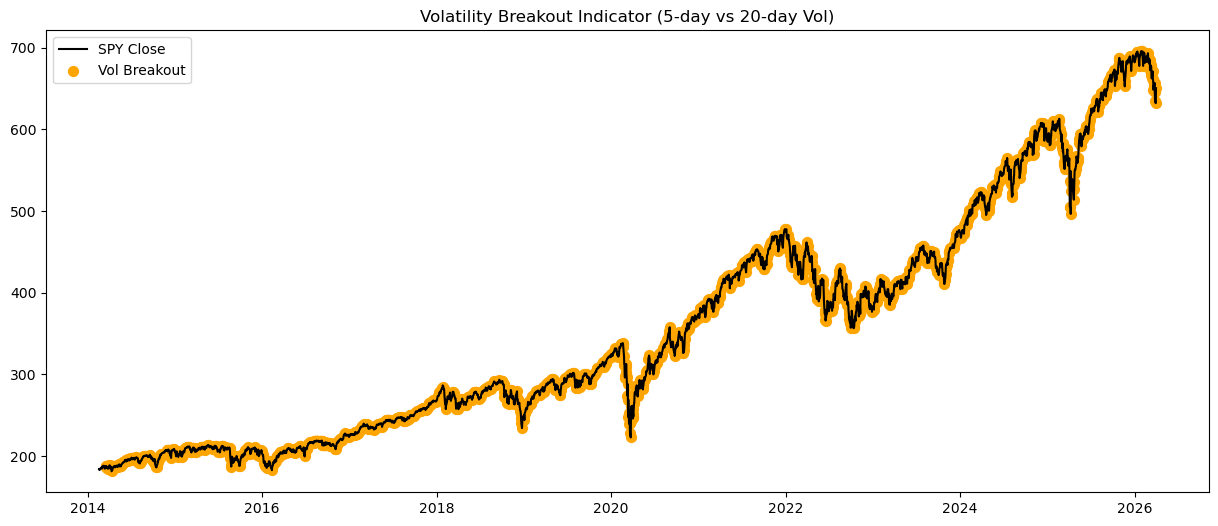

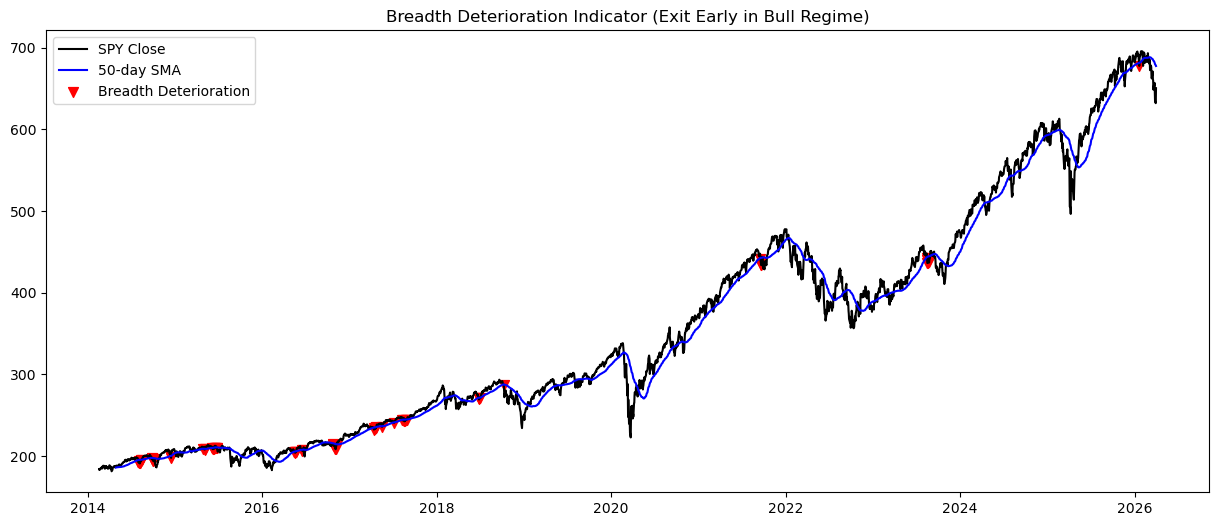

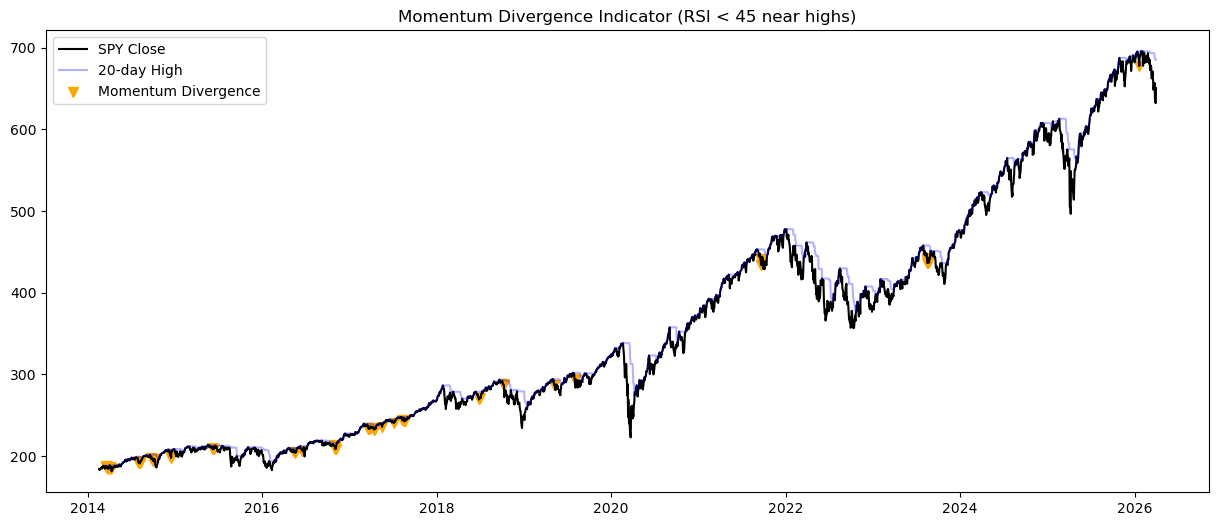

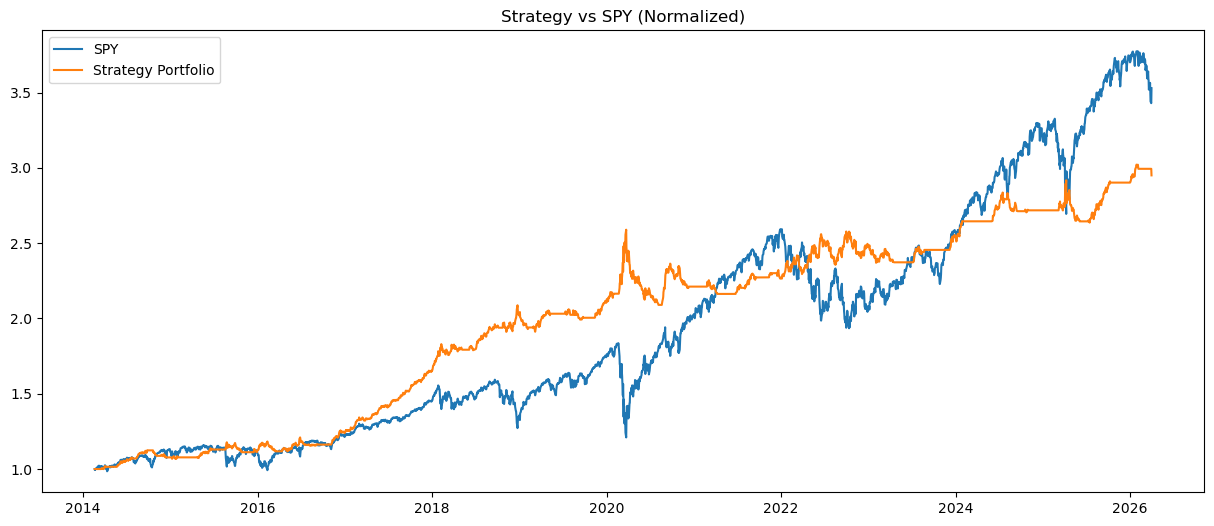

In [44]:
#Moving Average Crossover and Volatility Breakout Visualization
plt.figure(figsize=(15,6))
plt.plot(spy_data.index, spy_data['Close'], label='SPY Close', color='black')
plt.plot(spy_data.index, spy_data['EMA_fast'], label='3-period EMA', color='blue')
plt.plot(spy_data.index, spy_data['EMA_slow'], label='8-period EMA', color='red')

bear_signals = spy_data[spy_data['trend_exhaustion'] == -1]
plt.scatter(bear_signals.index, bear_signals['Close'], marker='v', color='red', label='Bear Warning', s=50)

bull_signals = spy_data[spy_data['trend_exhaustion'] == 1]
plt.scatter(bull_signals.index, bull_signals['Close'], marker='^', color='green', label='Bull Warning', s=50)

plt.legend()
plt.title("Trend Exhaustion Indicator (3/8 EMA Crossover)")
plt.show()

#Volatility Breakout Visualization
plt.figure(figsize=(15,6))
plt.plot(spy_data.index, spy_data['Close'], label='SPY Close', color='black')

breakouts = spy_data[spy_data['vol_breakout'] == 1]
plt.scatter(breakouts.index, breakouts['Close'], marker='o', color='orange', label='Vol Breakout', s=50)

plt.legend()
plt.title("Volatility Breakout Indicator (5-day vs 20-day Vol)")
plt.show()

#Breadth Deterioration Visualization (Exit Early in Bull Regime)
plt.figure(figsize=(15,6))
plt.plot(spy_data.index, spy_data['Close'], label='SPY Close', color='black')
plt.plot(spy_data.index, spy_data['SMA50'], label='50-day SMA', color='blue')

signals = spy_data[spy_data['breadth_deterioration'] == -1]
plt.scatter(signals.index, signals['Close'], marker='v', color='red', s=50, label='Breadth Deterioration')

plt.legend()
plt.title("Breadth Deterioration Indicator (Exit Early in Bull Regime)")
plt.show()

#Momentum Divergence Visualization (RSI < 45 near highs)
plt.figure(figsize=(15,6))
plt.plot(spy_data.index, spy_data['Close'], label='SPY Close', color='black')
plt.plot(spy_data.index, spy_data['High20'], label='20-day High', color='blue', alpha=0.3)

signals = spy_data[spy_data['momentum_divergence'] == -1]
plt.scatter(signals.index, signals['Close'], marker='v', color='orange', s=50, label='Momentum Divergence')

plt.legend()
plt.title("Momentum Divergence Indicator (RSI < 45 near highs)")
plt.show()

#Strategy vs SPY Performance Visualization (Normalized)
def normalize(series):
    return series / series.iloc[0]

plt.figure(figsize=(15,6))
plt.plot(spy_data.index, normalize(spy_data['Close']), label='SPY')
plt.plot(spy_data.index, normalize(spy_data['portfolio']), label='Strategy Portfolio')
plt.title("Strategy vs SPY (Normalized)")
plt.legend()
plt.show()

In [40]:
import numpy as np

daily_returns = spy_data['daily_portfolio_ret'].dropna()

mean_daily = daily_returns.mean()
std_daily = daily_returns.std()

trading_days = 252 
sharpe_ratio = (mean_daily / std_daily) * np.sqrt(trading_days)

print("Annualized Sharpe Ratio:", sharpe_ratio)

Annualized Sharpe Ratio: 1.0872396384018068


In [45]:
leverage = 1.5
spy_data['position_spy_leveraged'] = spy_data['position_spy'] * leverage

portfolio = 100000
portfolio_values = []

for i in range(len(spy_data)):
    if i == 0:
        portfolio_values.append(portfolio)
        continue
    
    daily_pnl = spy_data['position_spy_leveraged'].iloc[i] * portfolio * spy_data['ret_spy'].iloc[i]
    portfolio += daily_pnl
    portfolio_values.append(portfolio)

spy_data['portfolio_leveraged'] = portfolio_values

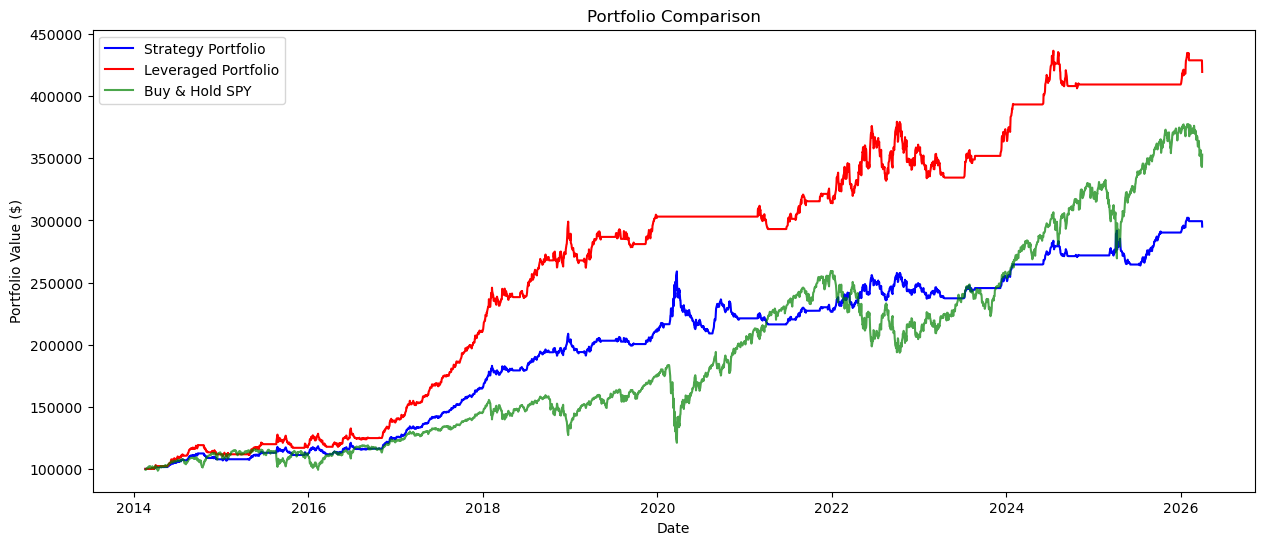

In [49]:
cash = 100000
spy_data['spy_return'] = spy_data['Close'].pct_change()
spy_data['buy_hold_portfolio'] = (1 + spy_data['spy_return']).cumprod() * cash

plt.figure(figsize=(15,6))
plt.plot(spy_data.index, spy_data['portfolio'], label='Strategy Portfolio', color='blue')
plt.plot(spy_data.index, spy_data['portfolio_leveraged'], label='Leveraged Portfolio', color='red')
plt.plot(spy_data.index, spy_data['buy_hold_portfolio'], label='Buy & Hold SPY', color='green', alpha=0.7)
plt.title('Portfolio Comparison')
plt.xlabel('Date')
plt.ylabel('Portfolio Value ($)')
plt.legend()
plt.show()